In [1]:
import json
import os
import time

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from ase import Atoms
import yaml

from fairchem.core.common.tutorial_utils import fairchem_main

from fairchem.core.datasets import LmdbDataset
from sklearn.metrics import r2_score, mean_absolute_error

/Users/xiaoenda/miniconda3/envs/MLFFopt_fairchem/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def collect_result(dft_path, prd_path, target, application=False):
    '''
    dft_path: input test set (lmdb format).
    prd_path: test prediction output, file name is ocp_predictions.npz 
    target  : target property name in lmdb
    application: Ture if the trained model is used for application.
                 False if it is used to collect output of test result.
    '''
    dft_raw = LmdbDataset({"src": dft_path})
    prd_raw = np.load(prd_path)
    # prd_raw.files

    if not application:
        dft = np.array([data[target] for data in dft_raw])
    
    # get ml result from output
    ids = [int(i.split('_')[1]) for i in prd_raw['ids']]
    inverse_ids = np.argsort(ids)
    prd = np.array([i[0] for i in prd_raw['energy']])
    prd = prd[inverse_ids]
    
    # create pandas dataframe
    dataset = LmdbDataset({"src": dft_path})
    data_list = []
    for ind, data in enumerate(dataset):
        # Customize keys depending on what's in each data sample
        row = {
            "id":     data.id,
            'UUID':   data.UUID,
            target + "_ML" : prd[ind],
        }
        if not application:
            row[target + "_DFT"] = dft[ind]
            # row[target + "_ML" ] = data[target]
            
        data_list.append(row)
    
    # Convert to DataFrame
    df = pd.DataFrame(data_list)
    
    return df

## This notebook contains:
1. Train a model of total magnetization from scratch.

The method and setting is same as the example 2. The target property is Mtot.

## Train model

In [4]:
run_dir = f"result_Mtot"   

job_name='Mtot_scratch'   

config    = f"./config_{job_name}.yml"
log_file  = f"log_train_{job_name}.txt"
warn_file = f"warn_train_{job_name}.txt"


In [ ]:
t0 = time.time()
! python {fairchem_main()} --mode train --config-yml {config}           \
                         --run-dir {run_dir}  --identifier {job_name} \
                         --print-every 50 \
                         --cpu  --optim.num_workers=0   \
                         > {log_file} 2>  {warn_file}
print(f'Elapsed time = {time.time() - t0:1.1f} seconds')

In [6]:
# Obtain output dir for later convenience.
# This dir contains trained model (checkpoint).  
cpline = !grep "checkpoint_dir:" {log_file}
cpdir  = cpline[0].split(':')[-1].strip()
print(cpdir)

result_Mtot/checkpoints/2025-10-09-18-55-12-Mtot_scratch


In [7]:
# copy config file to the ouput dir for future need.
! cp {config} {cpdir}'/config.yml'

## 3. Collect results of test set. 


In [8]:
# path to test lmdb set which should be same as the config file.
dft_path = "set_example_train/test.lmdb" 
# path to ML prediction; set automatically here
prd_path = cpdir.replace('checkpoints', 'results')  +'/ocp_predictions.npz'
print('Path to test set used for training: ', dft_path)
print('Path to test prediction by ML: ',      prd_path)

# The ML prediction and True values (DFT values) are collected to df and saved.
# target is the target property, which is the name in lmdb database and should be same as config file.
# application is Flase since we are not using model to predict new compounds.
df = collect_result(dft_path, prd_path, target='Mtot', application=False)
df.to_csv('./performance_test_scratch.csv')


Path to test set used for training:  set_example_train/test.lmdb
Path to test prediction by ML:  result_Mtot/results/2025-10-09-18-55-12-Mtot_scratch/ocp_predictions.npz


In [9]:
# the top 4 rows.
df.head(4)

,id,UUID,Mtot_ML,Mtot_DFT
0,18055,663356b2-eaea-4896-b56a-5373f386a30a,1.480469,1.931018
1,57884,6915b583-6995-4b8a-b2a3-df136c77cd16,1.119141,1.000000
2,43382,87c3755c-c8b8-4073-b831-f51ec179d236,0.714844,0.324434
3,9353,394b2839-218f-4316-8aac-2c13c6dfd206,0.722168,0.100346


#### Make a scatter plot with R2 and MAE
Here a scatter plot is used to understand the performance of the trained model. 
Please note, this is based on test set, not train set.

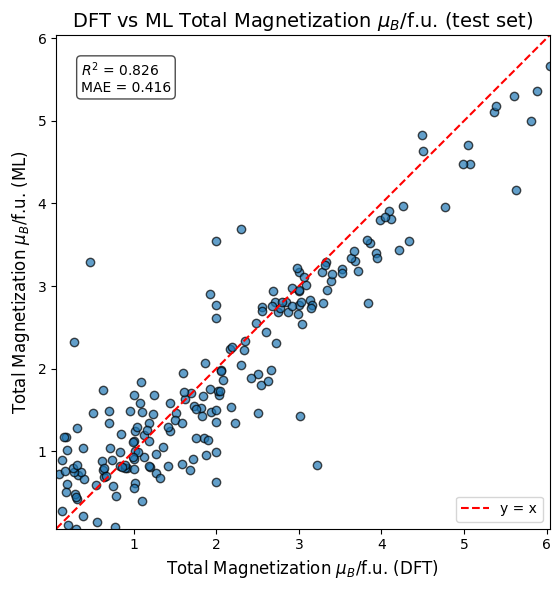

In [13]:
df = pd.read_csv('performance_test_scratch.csv', index_col=0)
target = 'Mtot'

# Compute metrics
r2 = r2_score(df[target+'_DFT'], df[target+'_ML'])
mae = mean_absolute_error(df[target+'_DFT'], df[target+'_ML'])

plt.figure(figsize=(6, 6))

# Scatter plot
plt.scatter(df[target+'_DFT'], df[target+'_ML'], alpha=0.7, edgecolor='k')

# 1:1 line
lims = [
    min(df[target+'_DFT'].min(), df[target+'_ML'].min()),
    max(df[target+'_DFT'].max(), df[target+'_ML'].max())
]
plt.plot(lims, lims, 'r--', label='y = x')

# Labels, title
plt.xlabel("Total Magnetization $\mu_B$/f.u. (DFT)", fontsize=12)
plt.ylabel("Total Magnetization $\mu_B$/f.u. (ML)", fontsize=12)
plt.title("DFT vs ML Total Magnetization $\mu_B$/f.u. (test set)", fontsize=14)

# Same scale for x and y
plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect('equal', adjustable='box')

# Add metrics as text inside plot
plt.text(0.05, 0.95, f"$R^2$ = {r2:.3f}\nMAE = {mae:.3f}",
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

plt.legend()
plt.tight_layout()
plt.show()


## 4. Application of the trained model
Now, we apply the trained model to predict formation energy of 2000 new compounds. 

Structures are stored in `set_example_apply/apply.lmdb` which is generated in previous tutorial.

In [16]:
# set path to lmdb of application dataset, 
set_apply='set_example_apply/apply.lmdb'

# set path to trained model
path_model = 'result_Mtot/checkpoints/2025-10-09-18-55-12-Mtot_scratch/'
config     = path_model + '/config.yml'
checkpoint = path_model + '/checkpoint.pt'

In [18]:
# create the application config file automatically
config_apply     = f"./config_apply.yml"
log_file_apply   = f"log_apply.txt"
warn_file_apply  = f"warn_apply.txt"

! cp {config} {config_apply}

# read config yml file
with open(config_apply) as f:
    config_yml = yaml.safe_load(f)
# change dir to application set
config_yml["dataset"]["test"]["src"] = set_apply
# save back to YAML
with open(config_apply, "w") as f:
    yaml.safe_dump(config_yml, f, sort_keys=False)

Now, use the trained model to do application.

In [19]:
t0 = time.time()
! python {fairchem_main()} --mode predict --config-yml {config_apply}  \
                           --run-dir {run_dir}  --identifier {job_name}'_apply' \
                           --checkpoint {checkpoint}  \
                           --cpu  --optim.num_workers=0   \
                           > {log_file_apply} 2>  {warn_file_apply}
print(f'Elapsed time = {time.time() - t0:1.1f} seconds')

Elapsed time = 25.2 seconds


In [20]:
# get result dir for collection
cpline = !grep "checkpoint_dir:" {log_file_apply}
cpdir_apply  = cpline[0].split(':')[-1].strip()
print(cpdir_apply)

result_Mtot/checkpoints/2025-10-09-19-37-52-Mtot_scratch_apply


In [21]:
dft_path = set_apply
prd_path = cpdir_apply.replace('checkpoints', 'results')  +'/ocp_predictions.npz'
print('Path to apply lmdb set: ', dft_path)
print('Path to prediction by ML: ',      prd_path)

df = collect_result(dft_path, prd_path, target='Mtot', application=True)
df.to_csv('result_application_scratch.csv')

Path to apply lmdb set:  set_example_apply/apply.lmdb
Path to prediction by ML:  result_Mtot/results/2025-10-09-19-37-52-Mtot_scratch_apply/ocp_predictions.npz


In [22]:
df.head(4)

,id,UUID,Mtot_ML
0,8025,35b02046-e21d-4f06-aaf9-0b608febaa1c,5.031250
1,5775,acd92db5-cde1-4835-b31a-aa00358153c1,2.607422
2,60302,6b5f6573-5d86-496c-a986-85196aade676,2.574219
3,33538,315f25de-a1b8-4472-ba6a-13fecce86378,1.085938
